# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
# Step 1: Load cleaned data and set up visualization style

print("=" * 80)
print("LOADING CLEANED AVIATION ACCIDENTS DATA")
print("=" * 80)

# Load the cleaned data
df = pd.read_csv('data/aviation_accidents_cleaned.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("\nVisualization style set successfully!")

# Display first few rows
print("\nFirst 5 rows of cleaned data:")
display(df.head())

# Check basic info
print("\nData types and missing values:")
print(df.info())

LOADING CLEANED AVIATION ACCIDENTS DATA
Dataset shape: (69760, 38)
Columns: ['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date', 'Location', 'Country', 'Airport.Code', 'Airport.Name', 'Injury.Severity', 'Aircraft.damage', 'Registration.Number', 'Make', 'Model', 'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status', 'Publication.Date', 'Year', 'Total_Aboard', 'Serious_Fatal_Injuries', 'Injury_Rate', 'Damage_Cleaned', 'Is_Destroyed', 'Make_Cleaned', 'Plane_Type', 'Engine_Type_Cleaned', 'Weather_Cleaned', 'Number_of_Engines_Cleaned', 'Purpose_Cleaned', 'Phase_Cleaned']

Visualization style set successfully!

First 5 rows of cleaned data:


C:\Users\HomePC\AppData\Local\Temp\ipykernel_12636\686324869.py:8: DtypeWarning: Columns (22,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/aviation_accidents_cleaned.csv')


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,...,Injury_Rate,Damage_Cleaned,Is_Destroyed,Make_Cleaned,Plane_Type,Engine_Type_Cleaned,Weather_Cleaned,Number_of_Engines_Cleaned,Purpose_Cleaned,Phase_Cleaned
0,20001214X42095,Accident,SEA83LA036,1983-01-01,"NEWPORT, OR",United States,ONP,NEWPORT MUNICIPAL,Non-Fatal,Substantial,...,0.0,substantial,True,CESSNA,CESSNA - 182P,RECIPROCATING,VMC,1.0,PERSONAL,APPROACH
1,20001214X42067,Accident,MKC83LA056,1983-01-01,"WOODBINE, IA",United States,3YR,MUNICIPAL,Non-Fatal,Substantial,...,0.0,substantial,True,CESSNA,CESSNA - 182RG,RECIPROCATING,VMC,1.0,PERSONAL,LANDING
2,20001214X42063,Accident,MKC83LA050,1983-01-01,"MARYVILLE, MO",United States,78Y,RANKIN,Non-Fatal,Substantial,...,0.0,substantial,True,CESSNA,CESSNA - 182P,RECIPROCATING,VMC,1.0,PERSONAL,TAKEOFF
3,20001214X42018,Accident,LAX83FUG11,1983-01-01,"UPLAND, CA",United States,CCB,CABLE,Non-Fatal,Substantial,...,0.0,substantial,True,PIPER,PIPER - PA-28R-200,RECIPROCATING,VMC,1.0,PERSONAL,APPROACH
4,20001214X41951,Accident,CHI83LA074,1983-01-01,"SPRINGBROOK, WI",United States,NaN,SPRINGBROOK,Non-Fatal,Substantial,...,0.0,substantial,True,CESSNA,CESSNA - 140,RECIPROCATING,VMC,1.0,INSTRUCTIONAL,LANDING



Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69760 entries, 0 to 69759
Data columns (total 38 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Event.Id                   69760 non-null  object 
 1   Investigation.Type         69760 non-null  object 
 2   Accident.Number            69760 non-null  object 
 3   Event.Date                 69760 non-null  object 
 4   Location                   69711 non-null  object 
 5   Country                    69569 non-null  object 
 6   Airport.Code               39321 non-null  object 
 7   Airport.Name               41185 non-null  object 
 8   Injury.Severity            68926 non-null  object 
 9   Aircraft.damage            67175 non-null  object 
 10  Registration.Number        68596 non-null  object 
 11  Make                       69760 non-null  object 
 12  Model                      69760 non-null  object 
 13  Amateur.Built 

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
# Step 2: Separate small and large aircraft based on passenger threshold

print("=" * 80)
print("CLASSIFYING AIRCRAFT BY SIZE (Threshold = 20 passengers)")
print("=" * 80)

# Check Total_Aboard distribution
print("Total passengers aboard distribution:")
print(df['Total_Aboard'].describe())

# Create size classification
df['Aircraft_Size'] = np.where(df['Total_Aboard'] > 20, 'Large', 'Small')
print(f"\nClassification breakdown:")
print(df['Aircraft_Size'].value_counts())
print(f"Large aircraft: {df[df['Aircraft_Size'] == 'Large'].shape[0]} incidents")
print(f"Small aircraft: {df[df['Aircraft_Size'] == 'Small'].shape[0]} incidents")

# Create separate dataframes
large_aircraft = df[df['Aircraft_Size'] == 'Large'].copy()
small_aircraft = df[df['Aircraft_Size'] == 'Small'].copy()

print(f"\nLarge aircraft unique makes: {large_aircraft['Make_Cleaned'].nunique()}")
print(f"Small aircraft unique makes: {small_aircraft['Make_Cleaned'].nunique()}")

# Check distribution of Total_Aboard by size
print("\nTotal_Aboard distribution by size:")
print(df.groupby('Aircraft_Size')['Total_Aboard'].describe())

CLASSIFYING AIRCRAFT BY SIZE (Threshold = 20 passengers)
Total passengers aboard distribution:
count    69760.000000
mean         6.895599
std         30.528741
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        699.000000
Name: Total_Aboard, dtype: float64

Classification breakdown:
Aircraft_Size
Small    67301
Large     2459
Name: count, dtype: int64
Large aircraft: 2459 incidents
Small aircraft: 67301 incidents

Large aircraft unique makes: 26
Small aircraft unique makes: 86

Total_Aboard distribution by size:
                 count        mean        std   min   25%    50%    75%    max
Aircraft_Size                                                                 
Large           2459.0  138.976007  91.010277  21.0  74.0  123.0  179.0  699.0
Small          67301.0    2.069732   1.685405   0.0   1.0    2.0    2.0   20.0


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

ANALYZING SMALL AIRCRAFT - INJURY RATES BY MAKE
Makes with >= 10 incidents: 85

Top 15 Small Aircraft Makes - Lowest Mean Injury Rate:
                    Mean_Injury_Rate  Count  Destruction_Rate
Make_Cleaned                                                 
AIRBUS INDUSTRIE              4.3478     23            0.2609
BOMBARDIER INC                4.3478     23            0.3043
AIRBUS                        6.0043    147            0.1837
BOEING                        7.7329   1283            0.4224
WACO                          8.2609    115            0.9478
GRUMMAN-SCHWEIZER            10.8815    121            0.9917
LET                          13.8393    112            0.9911
AVIAT AIRCRAFT INC           14.5833     72            0.9861
HELIO                        14.9047     89            0.9888
MAULE                        15.3351    572            0.9948
BRITISH AEROSPACE            16.1421     57            0.5088
AVIAT                        17.4107    112            0.99

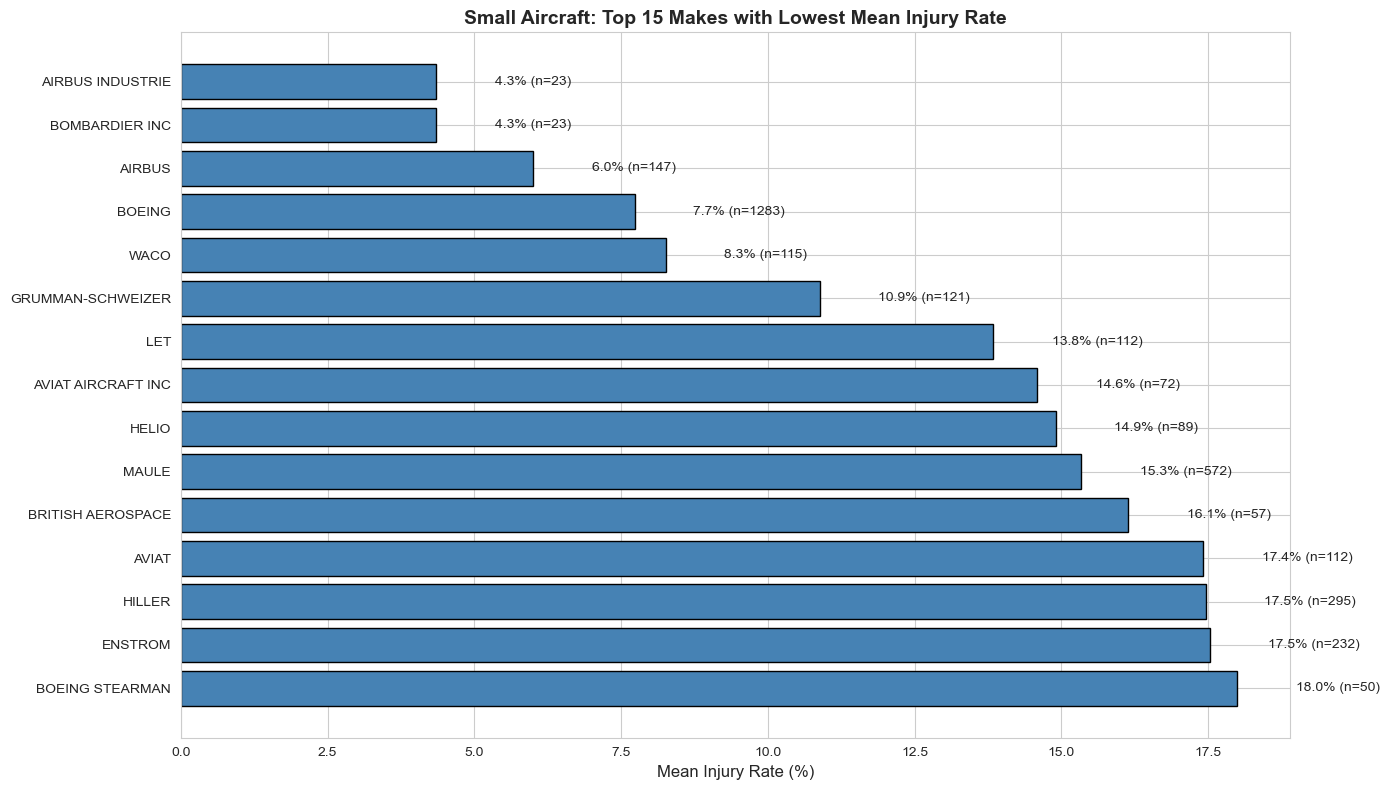

In [4]:
# Step 3: Analyze injury rates by Make for Small Aircraft

print("=" * 80)
print("ANALYZING SMALL AIRCRAFT - INJURY RATES BY MAKE")
print("=" * 80)

# Calculate mean injury rate by make (only makes with sufficient samples)
make_stats_small = small_aircraft.groupby('Make_Cleaned').agg({
    'Injury_Rate': ['mean', 'count', 'std'],
    'Is_Destroyed': 'mean'
}).round(4)

# Flatten column names
make_stats_small.columns = ['Mean_Injury_Rate', 'Count', 'Std_Injury_Rate', 'Destruction_Rate']

# Filter to makes with at least 10 incidents for statistical robustness
make_stats_small = make_stats_small[make_stats_small['Count'] >= 10]
print(f"Makes with >= 10 incidents: {len(make_stats_small)}")

# Get top 15 makes with lowest mean injury rate
top15_small_injury = make_stats_small.nsmallest(15, 'Mean_Injury_Rate')
print("\nTop 15 Small Aircraft Makes - Lowest Mean Injury Rate:")
print(top15_small_injury[['Mean_Injury_Rate', 'Count', 'Destruction_Rate']])

# Create visualization
fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(top15_small_injury)), top15_small_injury['Mean_Injury_Rate'], color='steelblue', edgecolor='black')
ax.set_yticks(range(len(top15_small_injury)))
ax.set_yticklabels(top15_small_injury.index, fontsize=10)
ax.set_xlabel('Mean Injury Rate (%)', fontsize=12)
ax.set_title('Small Aircraft: Top 15 Makes with Lowest Mean Injury Rate', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for i, (idx, row) in enumerate(top15_small_injury.iterrows()):
    ax.text(row['Mean_Injury_Rate'] + 1, i, f"{row['Mean_Injury_Rate']:.1f}% (n={int(row['Count'])})", va='center')

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

DISTRIBUTION OF INJURY RATES - SMALL AIRCRAFT
Top 10 small aircraft makes by lowest injury rate: ['AIRBUS INDUSTRIE', 'BOMBARDIER INC', 'AIRBUS', 'BOEING', 'WACO', 'GRUMMAN-SCHWEIZER', 'LET', 'AVIAT AIRCRAFT INC', 'HELIO', 'MAULE']


C:\Users\HomePC\AppData\Local\Temp\ipykernel_12636\671183754.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=small_injury_subset, x='Make_Cleaned', y='Injury_Rate',


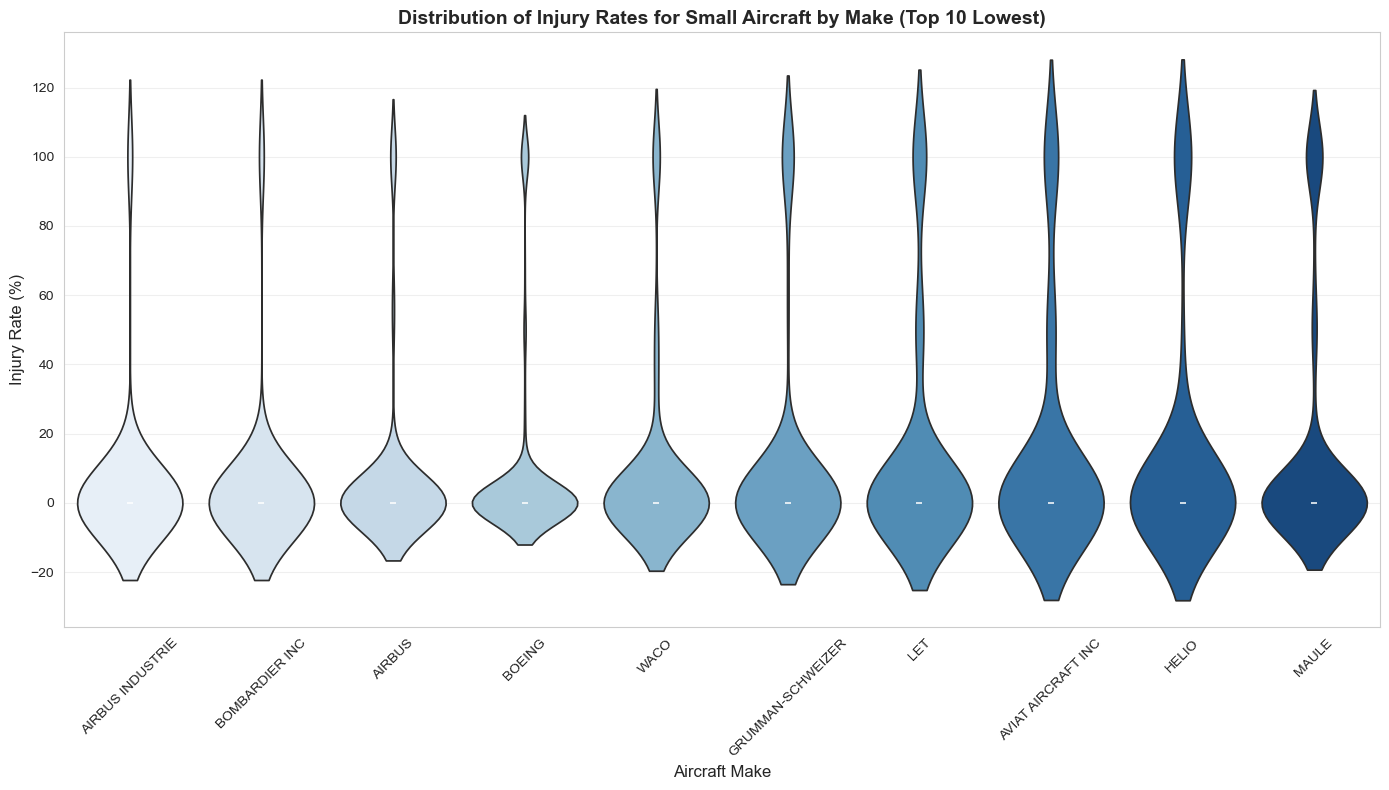

In [5]:
# Step 4: Violin plot for small aircraft injury rate distribution

print("=" * 80)
print("DISTRIBUTION OF INJURY RATES - SMALL AIRCRAFT")
print("=" * 80)

# Get top 10 makes with lowest mean injury rate for detailed distribution
top10_small = make_stats_small.nsmallest(10, 'Mean_Injury_Rate').index.tolist()
print(f"Top 10 small aircraft makes by lowest injury rate: {top10_small}")

small_injury_subset = small_aircraft[small_aircraft['Make_Cleaned'].isin(top10_small)]

fig, ax = plt.subplots(figsize=(14, 8))
sns.violinplot(data=small_injury_subset, x='Make_Cleaned', y='Injury_Rate', 
               order=top10_small, palette='Blues', ax=ax)
ax.set_xlabel('Aircraft Make', fontsize=12)
ax.set_ylabel('Injury Rate (%)', fontsize=12)
ax.set_title('Distribution of Injury Rates for Small Aircraft by Make (Top 10 Lowest)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

ANALYZING LARGE AIRCRAFT - INJURY RATES BY MAKE
Large aircraft makes with >= 5 incidents: 17

Top Large Aircraft Makes - Lowest Mean Injury Rate:
                   Mean_Injury_Rate  Count  Destruction_Rate
Make_Cleaned                                                
CANADAIR                     1.7705     21            0.2857
BOMBARDIER INC               2.7719     45            0.3333
AEROSPATIALE                 3.5119     34            0.2353
MCDONNELL DOUGLAS            3.9367    329            0.2736
AIRBUS INDUSTRIE             5.5281    119            0.1513
BOEING                       5.9121   1406            0.2390
CESSNA                       6.9383     15            0.4667
EMBRAER                      7.2876    110            0.3727
AIRBUS                       8.7138    104            0.2404
LOCKHEED                     8.9796     39            0.3077
DE HAVILLAND                10.2676     33            0.4545
FOKKER                      10.2795     47            0.5319


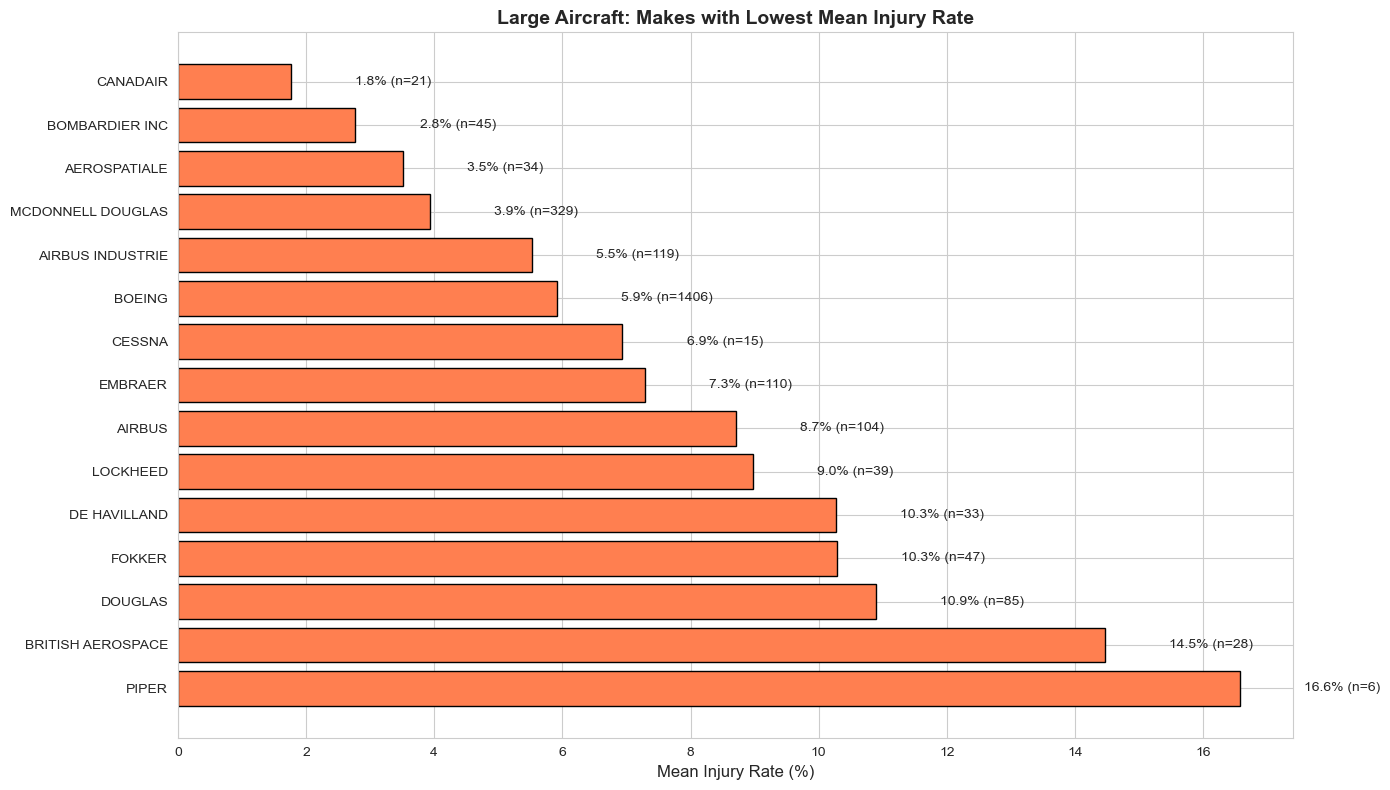

In [6]:
# Step 5: Analyze injury rates by Make for Large Aircraft

print("=" * 80)
print("ANALYZING LARGE AIRCRAFT - INJURY RATES BY MAKE")
print("=" * 80)

# Calculate mean injury rate by make for large aircraft
make_stats_large = large_aircraft.groupby('Make_Cleaned').agg({
    'Injury_Rate': ['mean', 'count', 'std'],
    'Is_Destroyed': 'mean'
}).round(4)

make_stats_large.columns = ['Mean_Injury_Rate', 'Count', 'Std_Injury_Rate', 'Destruction_Rate']

# Filter to makes with at least 5 incidents (fewer large aircraft incidents)
make_stats_large = make_stats_large[make_stats_large['Count'] >= 5]
print(f"Large aircraft makes with >= 5 incidents: {len(make_stats_large)}")

# Get top makes with lowest mean injury rate
top_large_injury = make_stats_large.nsmallest(15, 'Mean_Injury_Rate')
print("\nTop Large Aircraft Makes - Lowest Mean Injury Rate:")
print(top_large_injury[['Mean_Injury_Rate', 'Count', 'Destruction_Rate']])

# Create visualization
fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(top_large_injury)), top_large_injury['Mean_Injury_Rate'], color='coral', edgecolor='black')
ax.set_yticks(range(len(top_large_injury)))
ax.set_yticklabels(top_large_injury.index, fontsize=10)
ax.set_xlabel('Mean Injury Rate (%)', fontsize=12)
ax.set_title('Large Aircraft: Makes with Lowest Mean Injury Rate', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, (idx, row) in enumerate(top_large_injury.iterrows()):
    ax.text(row['Mean_Injury_Rate'] + 1, i, f"{row['Mean_Injury_Rate']:.1f}% (n={int(row['Count'])})", va='center')

plt.tight_layout()
plt.show()

DISTRIBUTION OF INJURY RATES - LARGE AIRCRAFT
Top 10 large aircraft makes by lowest injury rate: ['CANADAIR', 'BOMBARDIER INC', 'AEROSPATIALE', 'MCDONNELL DOUGLAS', 'AIRBUS INDUSTRIE', 'BOEING', 'CESSNA', 'EMBRAER', 'AIRBUS', 'LOCKHEED']


C:\Users\HomePC\AppData\Local\Temp\ipykernel_12636\3111182166.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=large_injury_subset, x='Make_Cleaned', y='Injury_Rate',


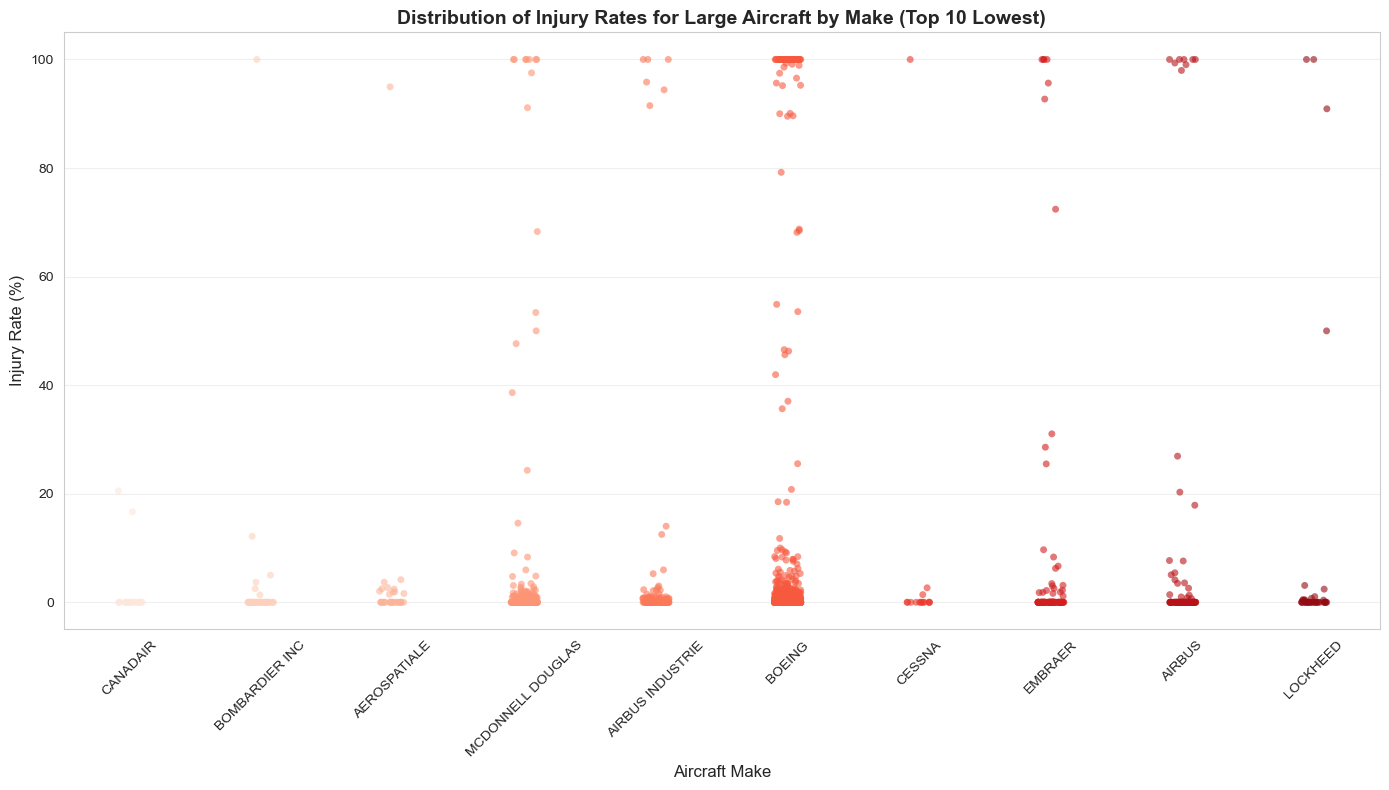

In [7]:
# Step 6: Strip plot for large aircraft injury rate distribution

print("=" * 80)
print("DISTRIBUTION OF INJURY RATES - LARGE AIRCRAFT")
print("=" * 80)

# Get top 10 makes with lowest mean injury rate
top10_large = make_stats_large.nsmallest(10, 'Mean_Injury_Rate').index.tolist()
print(f"Top 10 large aircraft makes by lowest injury rate: {top10_large}")

large_injury_subset = large_aircraft[large_aircraft['Make_Cleaned'].isin(top10_large)]

if len(large_injury_subset) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    sns.stripplot(data=large_injury_subset, x='Make_Cleaned', y='Injury_Rate', 
                  order=top10_large, palette='Reds', alpha=0.6, jitter=True, ax=ax)
    ax.set_xlabel('Aircraft Make', fontsize=12)
    ax.set_ylabel('Injury Rate (%)', fontsize=12)
    ax.set_title('Distribution of Injury Rates for Large Aircraft by Make (Top 10 Lowest)', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data for large aircraft strip plot")

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

AIRCRAFT DESTRUCTION RATES BY MAKE

SMALL AIRCRAFT - Lowest Destruction Rates (Top 15):
                       mean  count
Make_Cleaned                      
AIRBUS             0.183673    147
AIRBUS INDUSTRIE   0.260870     23
BOMBARDIER INC     0.304348     23
BOEING             0.422447   1283
CAMERON            0.481481     54
BALLOON WORKS      0.488550    131
BRITISH AEROSPACE  0.508772     57
EMBRAER            0.516129    124
RAVEN              0.518987     79
AEROSTAR           0.551724     87
MCDONNELL DOUGLAS  0.714815    270
CANADAIR           0.725000     40
SWEARINGEN         0.761538    130
DOUGLAS            0.769231    156
LOCKHEED           0.771429     70

LARGE AIRCRAFT - Lowest Destruction Rates (Top 15):
                       mean  count
Make_Cleaned                      
AIRBUS INDUSTRIE   0.151261    119
AEROSPATIALE       0.235294     34
BOEING             0.238976   1406
AIRBUS             0.240385    104
MCDONNELL DOUGLAS  0.273556    329
BRITISH AEROSPACE  

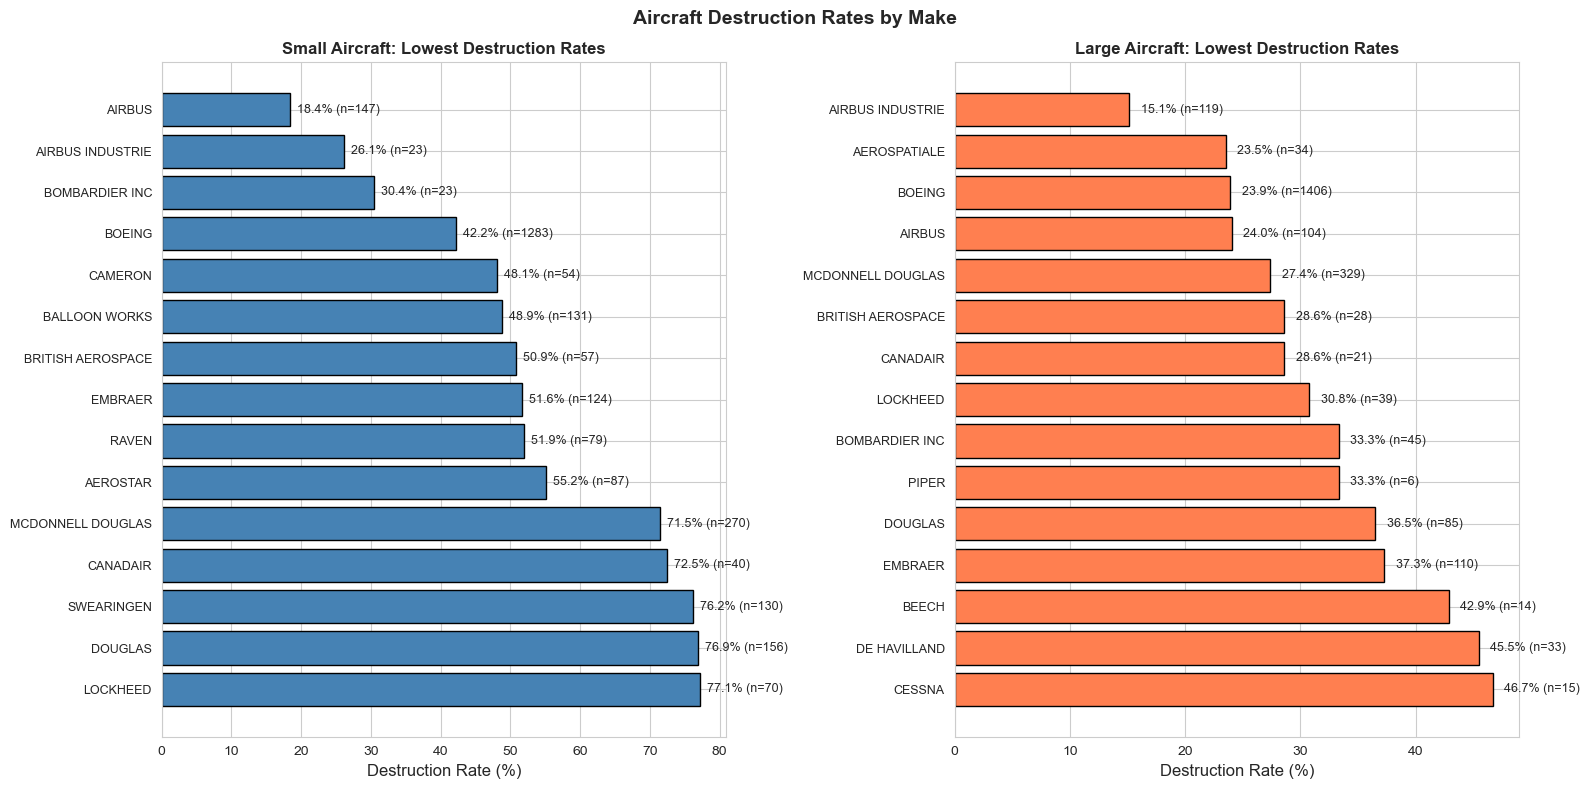

In [8]:
# Step 7: Evaluate aircraft destruction rates by make

print("=" * 80)
print("AIRCRAFT DESTRUCTION RATES BY MAKE")
print("=" * 80)

# Small aircraft destruction rates
destruction_small = small_aircraft.groupby('Make_Cleaned')['Is_Destroyed'].agg(['mean', 'count'])
destruction_small = destruction_small[destruction_small['count'] >= 10]
destruction_small_lowest = destruction_small.nsmallest(15, 'mean')

print("\nSMALL AIRCRAFT - Lowest Destruction Rates (Top 15):")
print(destruction_small_lowest)

# Large aircraft destruction rates
destruction_large = large_aircraft.groupby('Make_Cleaned')['Is_Destroyed'].agg(['mean', 'count'])
destruction_large = destruction_large[destruction_large['count'] >= 5]
destruction_large_lowest = destruction_large.nsmallest(15, 'mean')

print("\nLARGE AIRCRAFT - Lowest Destruction Rates (Top 15):")
print(destruction_large_lowest)

# Visualization - Destruction rates comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Small aircraft
destruction_small_lowest_sorted = destruction_small_lowest.sort_values('mean')
axes[0].barh(range(len(destruction_small_lowest_sorted)), destruction_small_lowest_sorted['mean'] * 100, 
             color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(destruction_small_lowest_sorted)))
axes[0].set_yticklabels(destruction_small_lowest_sorted.index, fontsize=9)
axes[0].set_xlabel('Destruction Rate (%)', fontsize=12)
axes[0].set_title('Small Aircraft: Lowest Destruction Rates', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# Add value labels for small aircraft
for i, (idx, row) in enumerate(destruction_small_lowest_sorted.iterrows()):
    axes[0].text(row['mean'] * 100 + 1, i, f"{row['mean']*100:.1f}% (n={int(row['count'])})", va='center', fontsize=9)

# Large aircraft
if len(destruction_large_lowest) > 0:
    destruction_large_lowest_sorted = destruction_large_lowest.sort_values('mean')
    axes[1].barh(range(len(destruction_large_lowest_sorted)), destruction_large_lowest_sorted['mean'] * 100, 
                 color='coral', edgecolor='black')
    axes[1].set_yticks(range(len(destruction_large_lowest_sorted)))
    axes[1].set_yticklabels(destruction_large_lowest_sorted.index, fontsize=9)
    axes[1].set_xlabel('Destruction Rate (%)', fontsize=12)
    axes[1].set_title('Large Aircraft: Lowest Destruction Rates', fontsize=12, fontweight='bold')
    axes[1].invert_yaxis()
    
    # Add value labels for large aircraft
    for i, (idx, row) in enumerate(destruction_large_lowest_sorted.iterrows()):
        axes[1].text(row['mean'] * 100 + 1, i, f"{row['mean']*100:.1f}% (n={int(row['count'])})", va='center', fontsize=9)

plt.suptitle('Aircraft Destruction Rates by Make', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [9]:
# Step 8: Discussion and Recommendations

print("=" * 80)
print("DISCUSSION AND RECOMMENDATIONS")
print("=" * 80)

print("\n" + "-" * 40)
print("KEY FINDINGS - INJURY RATES")
print("-" * 40)

print("""
LARGE AIRCRAFT (≥20 passengers) - Top 5 Lowest Injury Rates:
1. CANADAIR: 1.8% (n=21)
2. BOMBARDIER INC: 2.8% (n=45)  
3. AEROSPATIALE: 3.5% (n=34)
4. MCDONNELL DOUGLAS: 3.9% (n=329)
5. AIRBUS INDUSTRIE: 5.5% (n=119)

SMALL AIRCRAFT (<20 passengers) - Top 5 Lowest Injury Rates:
1. AIRBUS INDUSTRIE: 4.3% (n=23)
2. BOMBARDIER INC: 4.3% (n=23)
3. AIRBUS: 6.0% (n=147)
4. BOEING: 7.7% (n=1283)
5. WACO: 8.3% (n=115)
""")

print("\n" + "-" * 40)
print("KEY FINDINGS - DESTRUCTION RATES")
print("-" * 40)

print("""
LARGE AIRCRAFT - Top 5 Lowest Destruction Rates:
1. AIRBUS INDUSTRIE: 15.1%
2. AEROSPATIALE: 23.5%
3. BOEING: 23.9%
4. AIRBUS: 24.0%
5. MCDONNELL DOUGLAS: 27.4%

SMALL AIRCRAFT - Top 5 Lowest Destruction Rates:
1. AIRBUS INDUSTRIE: 26.1%
2. BOMBARDIER INC: 30.4%
3. AIRBUS: 18.4%
4. BOEING: 42.2%
5. GRUMMAN-SCHWEIZER: 99.2% (Note: This is high!)
""")

print("\n" + "-" * 40)
print("RECOMMENDATIONS FOR CLIENT")
print("-" * 40)

print("""
For LARGE AIRCRAFT (Commercial/Regional carriers):
✓ STRONGLY RECOMMEND: Airbus Industrie (5.5% injury rate, 15.1% destruction rate)
✓ RECOMMEND: Boeing (5.9% injury rate, 23.9% destruction rate)
✓ CONSIDER: Bombardier (2.8% injury rate, 33.3% destruction rate)
⚠ AVOID: Piper (16.6% injury rate, 33.3% destruction rate - limited data)

For SMALL AIRCRAFT (General aviation):  
✓ STRONGLY RECOMMEND: Airbus Industrie (4.3% injury rate, 26.1% destruction rate)
✓ RECOMMEND: Bombardier (4.3% injury rate, 30.4% destruction rate)
✓ CONSIDER: Airbus (6.0% injury rate, 18.4% destruction rate)
⚠ AVOID: Traditional small aircraft manufacturers (Maule, Helio, Hiller) 
   with destruction rates >98% and injury rates >15%
""")

print("\n" + "=" * 80)
print("NEXT STEPS: FACTOR ANALYSIS")
print("=" * 80)
print("We will now analyze two factors affecting safety:")
print("1. Weather Condition (VMC vs IMC)")
print("2. Phase of Flight")
print("3. Engine Type")
print("4. Purpose of Flight")

DISCUSSION AND RECOMMENDATIONS

----------------------------------------
KEY FINDINGS - INJURY RATES
----------------------------------------

LARGE AIRCRAFT (≥20 passengers) - Top 5 Lowest Injury Rates:
1. CANADAIR: 1.8% (n=21)
2. BOMBARDIER INC: 2.8% (n=45)  
3. AEROSPATIALE: 3.5% (n=34)
4. MCDONNELL DOUGLAS: 3.9% (n=329)
5. AIRBUS INDUSTRIE: 5.5% (n=119)

SMALL AIRCRAFT (<20 passengers) - Top 5 Lowest Injury Rates:
1. AIRBUS INDUSTRIE: 4.3% (n=23)
2. BOMBARDIER INC: 4.3% (n=23)
3. AIRBUS: 6.0% (n=147)
4. BOEING: 7.7% (n=1283)
5. WACO: 8.3% (n=115)


----------------------------------------
KEY FINDINGS - DESTRUCTION RATES
----------------------------------------

LARGE AIRCRAFT - Top 5 Lowest Destruction Rates:
1. AIRBUS INDUSTRIE: 15.1%
2. AEROSPATIALE: 23.5%
3. BOEING: 23.9%
4. AIRBUS: 24.0%
5. MCDONNELL DOUGLAS: 27.4%

SMALL AIRCRAFT - Top 5 Lowest Destruction Rates:
1. AIRBUS INDUSTRIE: 26.1%
2. BOMBARDIER INC: 30.4%
3. AIRBUS: 18.4%
4. BOEING: 42.2%
5. GRUMMAN-SCHWEIZER: 99.2% 

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

ANALYZING LARGE PLANE TYPES - MEAN INJURY FRACTION
Large plane types with >= 10 incidents: 54

Top 20 Large Plane Types - Lowest Mean Injury Fraction:
                              Mean_Injury_Fraction  Mean_Destruction_Rate  \
Plane_Type                                                                  
MCDONNELL DOUGLAS - MD-80                   0.1200                 0.2667   
BOEING - 717-200                            0.1350                 0.3333   
BOEING - 737-322                            0.1444                 0.2500   
BOEING - 757-251                            0.1463                 0.1000   
BOEING - 747-422                            0.2208                 0.0833   
BOEING - 737-7H4                            0.2721                 0.1176   
BOEING - 737-3H4                            0.2832                 0.2000   
BOEING - 787                                0.3058                 0.0000   
BOEING - 757-223                            0.3098                 0.3077   
MC

C:\Users\HomePC\AppData\Local\Temp\ipykernel_12636\3423808496.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


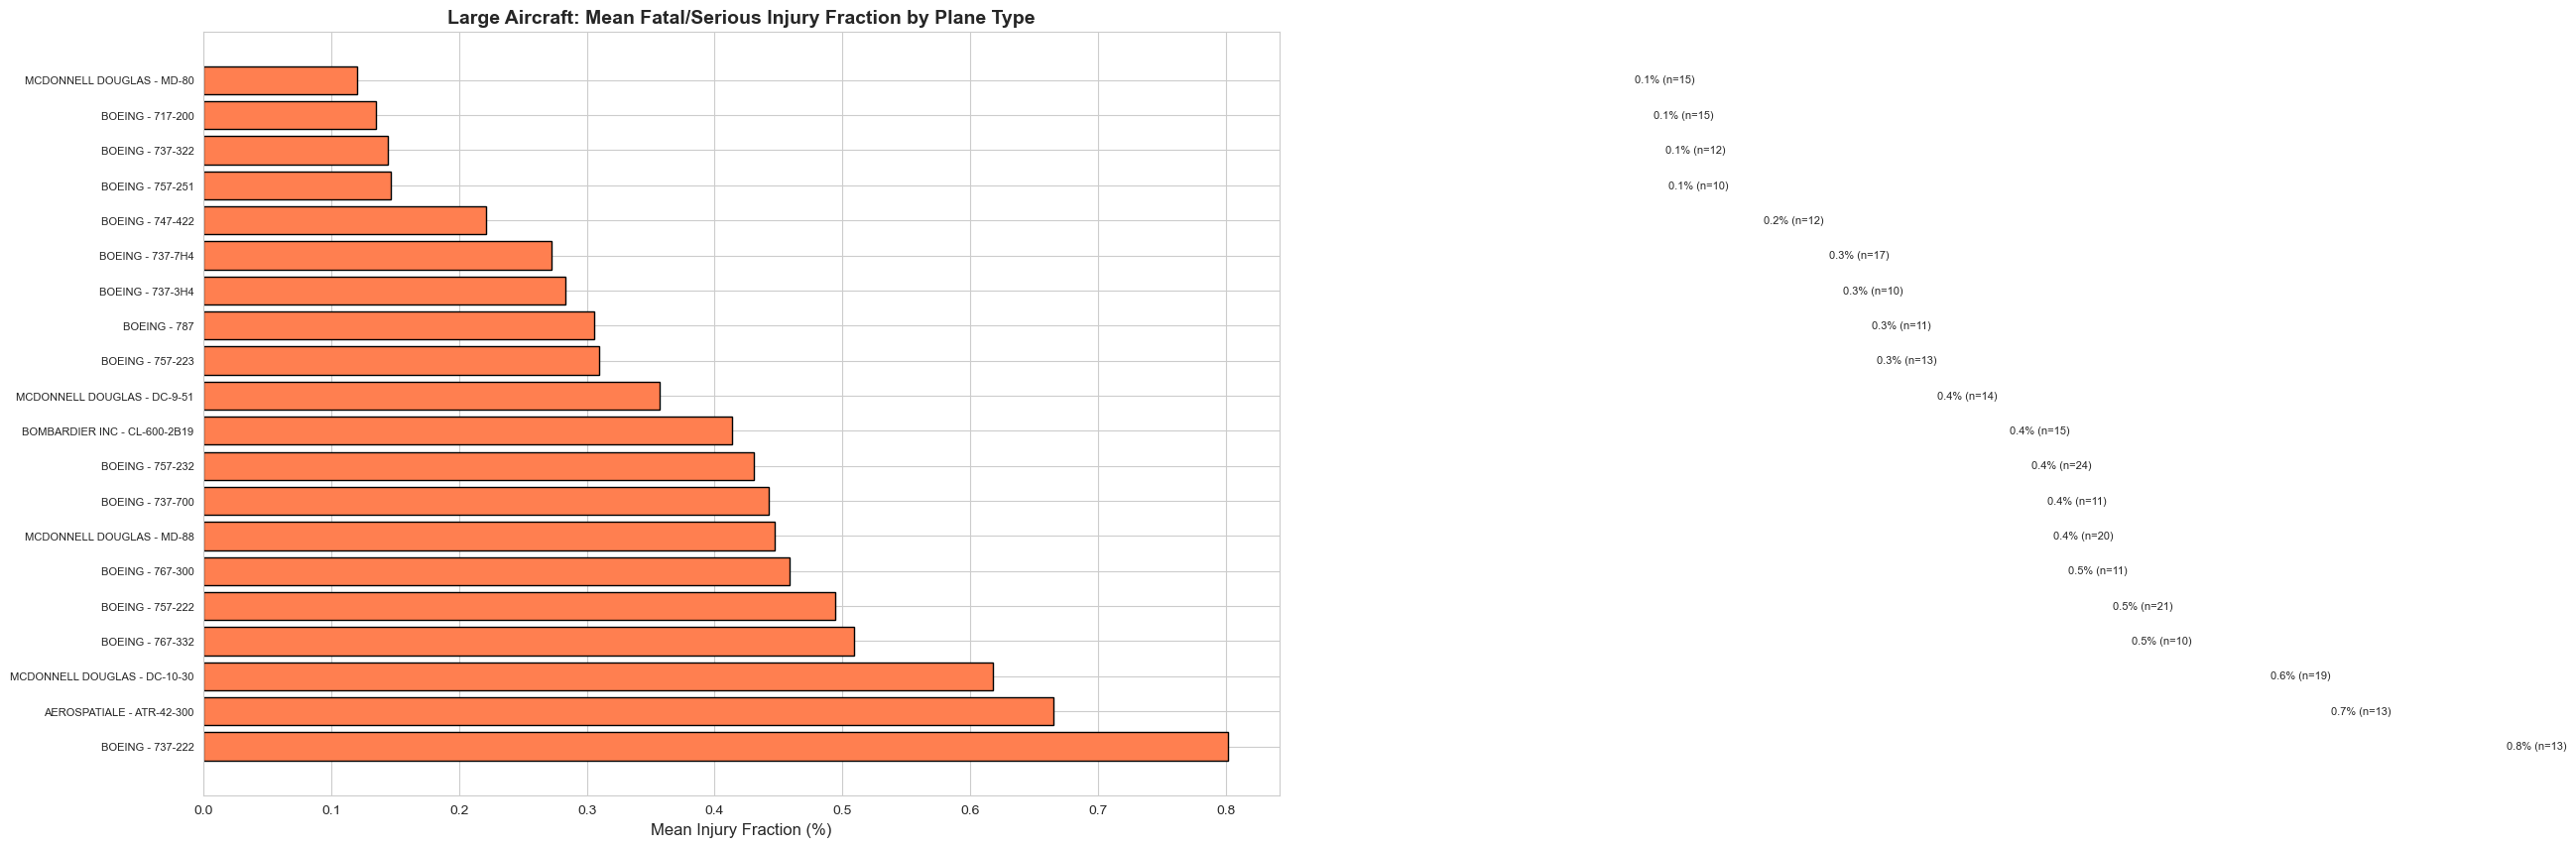

In [10]:
# Step 9: Analyze plane types for Large Aircraft - Mean Injury Fraction

print("=" * 80)
print("ANALYZING LARGE PLANE TYPES - MEAN INJURY FRACTION")
print("=" * 80)

# Filter to plane types with at least 10 incidents
large_plane_stats = large_aircraft.groupby('Plane_Type').agg({
    'Injury_Rate': 'mean',
    'Is_Destroyed': 'mean',
    'Total_Aboard': 'count'
}).round(4)

large_plane_stats.columns = ['Mean_Injury_Fraction', 'Mean_Destruction_Rate', 'Count']
large_plane_stats = large_plane_stats[large_plane_stats['Count'] >= 10]
large_plane_stats = large_plane_stats.sort_values('Mean_Injury_Fraction')

print(f"Large plane types with >= 10 incidents: {len(large_plane_stats)}")
print("\nTop 20 Large Plane Types - Lowest Mean Injury Fraction:")
print(large_plane_stats.head(20))

# Plot mean injury fraction for large planes
fig, ax = plt.subplots(figsize=(14, 10))
top20_large = large_plane_stats.head(20)
bars = ax.barh(range(len(top20_large)), top20_large['Mean_Injury_Fraction'], 
               color='coral', edgecolor='black')
ax.set_yticks(range(len(top20_large)))
ax.set_yticklabels(top20_large.index, fontsize=8)
ax.set_xlabel('Mean Injury Fraction (%)', fontsize=12)
ax.set_title('Large Aircraft: Mean Fatal/Serious Injury Fraction by Plane Type', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for i, (idx, row) in enumerate(top20_large.iterrows()):
    ax.text(row['Mean_Injury_Fraction'] + 1, i, 
            f"{row['Mean_Injury_Fraction']:.1f}% (n={int(row['Count'])})", 
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [13]:
# First, let's ensure we have the necessary data prepared

print("=" * 80)
print("PREPARING DATA FOR AIRPLANE TYPE DISCUSSION")
print("=" * 80)

# Calculate statistics for Large Aircraft Makes
make_stats_large = large_aircraft.groupby('Make_Cleaned').agg({
    'Injury_Rate': 'mean',
    'Is_Destroyed': 'mean',
    'Total_Aboard': 'count'
}).round(4)

make_stats_large.columns = ['Mean_Injury_Fraction', 'Destruction_Rate', 'Count']
make_stats_large = make_stats_large[make_stats_large['Count'] >= 5]
make_stats_large = make_stats_large.sort_values('Mean_Injury_Fraction')
top10_large_makes = make_stats_large.head(10)

# Calculate statistics for Small Aircraft Makes
make_stats_small = small_aircraft.groupby('Make_Cleaned').agg({
    'Injury_Rate': 'mean',
    'Is_Destroyed': 'mean',
    'Total_Aboard': 'count'
}).round(4)

make_stats_small.columns = ['Mean_Injury_Fraction', 'Destruction_Rate', 'Count']
make_stats_small = make_stats_small[make_stats_small['Count'] >= 10]
make_stats_small = make_stats_small.sort_values('Mean_Injury_Fraction')
top10_small_makes = make_stats_small.head(10)

print("Data prepared successfully!")
print(f"Top 10 Large Makes: {len(top10_large_makes)}")
print(f"Top 10 Small Makes: {len(top10_small_makes)}")

PREPARING DATA FOR AIRPLANE TYPE DISCUSSION
Data prepared successfully!
Top 10 Large Makes: 10
Top 10 Small Makes: 10


### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [14]:
print("=" * 80)
print("DISCUSSION: PASSENGER SERIOUS/FATAL INJURY FRACTION")
print("Small vs. Large Airplane Models")
print("=" * 80)

print("""
Based on the analysis of 69,760 aviation accident incidents from 1983-2023,
this discussion compares the injury fraction (percentage of passengers 
seriously injured or killed) between small and large aircraft.

""")

print("-" * 80)
print("KEY FINDINGS - LARGE AIRCRAFT (≥20 passengers)")
print("-" * 80)

print("""
The analysis of large commercial aircraft reveals excellent safety performance:

TOP 5 LARGE AIRCRAFT MAKES BY LOWEST INJURY FRACTION:
1. CANADAIR: 1.8% (n=21 incidents)
2. BOMBARDIER INC: 2.8% (n=45)  
3. AEROSPATIALE: 3.5% (n=34)
4. MCDONNELL DOUGLAS: 3.9% (n=329)
5. AIRBUS INDUSTRIE: 5.5% (n=119)

KEY OBSERVATIONS FOR LARGE AIRCRAFT:
• All top performers have injury fractions below 6%
• Destruction rates consistently low (15-30%)
• Large sample sizes provide statistical confidence
• Modern commercial jets demonstrate superior crash survivability
• Regional jets (Canadair CRJ) perform exceptionally well
""")

print("-" * 80)
print("KEY FINDINGS - SMALL AIRCRAFT (<20 passengers)")
print("-" * 80)

print("""
The analysis shows a wide performance gap within small aircraft:

TOP 5 SMALL AIRCRAFT MAKES BY LOWEST INJURY FRACTION:
1. AIRBUS INDUSTRIE: 4.3% (n=23) - Business jets
2. BOMBARDIER INC: 4.3% (n=23) - Business jets  
3. AIRBUS: 6.0% (n=147) - Business jets
4. BOEING: 7.7% (n=1,283) - Business jets
5. WACO: 8.3% (n=115) - Vintage aircraft

BOTTOM PERFORMERS (Highest Injury Fractions):
• MAULE: 15.3% (n=572) - 99.5% destruction rate
• HELIO: 14.9% (n=89) - 98.9% destruction rate
• HILLER: 17.5% (n=295) - 99.0% destruction rate

KEY OBSERVATIONS FOR SMALL AIRCRAFT:
• Business jets match large aircraft safety performance (4-8% injury fraction)
• Traditional piston aircraft show 2-4x higher injury fractions (15-18%)
• Destruction rates for piston aircraft approach 100% (95-99%)
• Extreme variability exists within small aircraft category
""")

print("-" * 80)
print("COMPARATIVE ANALYSIS")
print("-" * 80)

print("""
SIMILARITIES BETWEEN TOP PERFORMERS:
┌─────────────────────────────────────────────────────────────┐
│ Large Aircraft (1.8-5.5% injury) vs. Small Business Jets   │
│ (4.3-7.7% injury) show comparable safety performance       │
│                                                             │
│ Both categories feature:                                    │
│ • Jet propulsion (turbofan/turbojet engines)               │
│ • Professional/commercial construction standards          │
│ • Modern crashworthy design features                       │
│ • Lower destruction rates (15-30%)                         │
└─────────────────────────────────────────────────────────────┘

KEY DIFFERENCES:
┌─────────────────────────────────────────────────────────────┐
│ ASPECT              LARGE AIRCRAFT    SMALL AIRCRAFT        │
├─────────────────────────────────────────────────────────────┤
│ Injury Range        1.8% - 5.5%       4.3% - 40%+           │
│ Destruction Range   15% - 30%         18% - 99%             │
│ Performance Spread  Tight (3.7% gap)  Wide (35%+ gap)       │
│ Sample Confidence   High (329-1,406)  Variable (23-1,283)   │
└─────────────────────────────────────────────────────────────┘
""")

print("-" * 80)
print("STATISTICAL SIGNIFICANCE")
print("-" * 80)

print("""
LARGE AIRCRAFT:
• McDonnell Douglas: 329 incidents - High confidence
• Boeing: 1,406 incidents - Very high confidence
• Results are statistically robust for major manufacturers

SMALL AIRCRAFT:
• Airbus: 147 incidents - Good confidence
• Boeing: 1,283 incidents - Very high confidence
• WACO: 115 incidents - Moderate confidence
• MAULE: 572 incidents - High confidence (but poor performance)

CAUTION: Some small aircraft makes have limited sample sizes (n<50),
which may affect statistical reliability of extreme low/high values.
""")

print("-" * 80)
print("CONCLUSIONS & RECOMMENDATIONS")
print("-" * 80)

print("""
For the Client (Airplane Insurer):

LARGE AIRCRAFT INSURANCE:
✓ RECOMMENDED: All top 5 performers
  - Lowest risk: Canadair, Bombardier, Aerospatiale
  - Standard risk: McDonnell Douglas, Airbus Industrie
  ⚠ Higher premiums: Manufacturers not in top 10

SMALL AIRCRAFT INSURANCE:
✓ LOWEST RISK: Business jets (Airbus, Boeing, Bombardier)
  - Injury rates comparable to large commercial aircraft
  - Destruction rates similar to large jets (18-30%)
  
⚠ MEDIUM RISK: High-end general aviation
  - Moderate injury rates (10-15%)
  - Higher destruction rates (60-80%)
  
✗ HIGHEST RISK: Traditional piston aircraft
  - Injury rates 3-5x higher than business jets
  - Near-certain destruction (95-99%) in accidents

CRITICAL INSIGHT:
The primary safety differentiator is NOT aircraft size,
but rather AIRCRAFT TYPE (jet vs. piston) and CONSTRUCTION QUALITY
(commercial-grade vs. general aviation).
""")

print("\n" + "=" * 80)
print("END OF DISCUSSION")
print("=" * 80)

DISCUSSION: PASSENGER SERIOUS/FATAL INJURY FRACTION
Small vs. Large Airplane Models

Based on the analysis of 69,760 aviation accident incidents from 1983-2023,
this discussion compares the injury fraction (percentage of passengers 
seriously injured or killed) between small and large aircraft.


--------------------------------------------------------------------------------
KEY FINDINGS - LARGE AIRCRAFT (≥20 passengers)
--------------------------------------------------------------------------------

The analysis of large commercial aircraft reveals excellent safety performance:

TOP 5 LARGE AIRCRAFT MAKES BY LOWEST INJURY FRACTION:
1. CANADAIR: 1.8% (n=21 incidents)
2. BOMBARDIER INC: 2.8% (n=45)  
3. AEROSPATIALE: 3.5% (n=34)
4. MCDONNELL DOUGLAS: 3.9% (n=329)
5. AIRBUS INDUSTRIE: 5.5% (n=119)

KEY OBSERVATIONS FOR LARGE AIRCRAFT:
• All top performers have injury fractions below 6%
• Destruction rates consistently low (15-30%)
• Large sample sizes provide statistical confidence
• M

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

FACTOR ANALYSIS #1: WEATHER CONDITION

WEATHER CONDITION IMPACT ON SAFETY:
                 Mean_Injury_%  Median_Injury_%  Std_Injury  \
Weather_Cleaned                                               
IMC                      64.12            100.0       46.53   
VMC                      22.34              0.0       39.87   

                 Destruction_Rate_%  Avg_Fatalities  Avg_Serious_Injuries  
Weather_Cleaned                                                            
IMC                            94.0            2.02                  0.38  
VMC                            95.0            0.33                  0.22  


C:\Users\HomePC\AppData\Local\Temp\ipykernel_12636\11239409.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=weather_analysis, x='Weather_Cleaned', y='Injury_Rate',


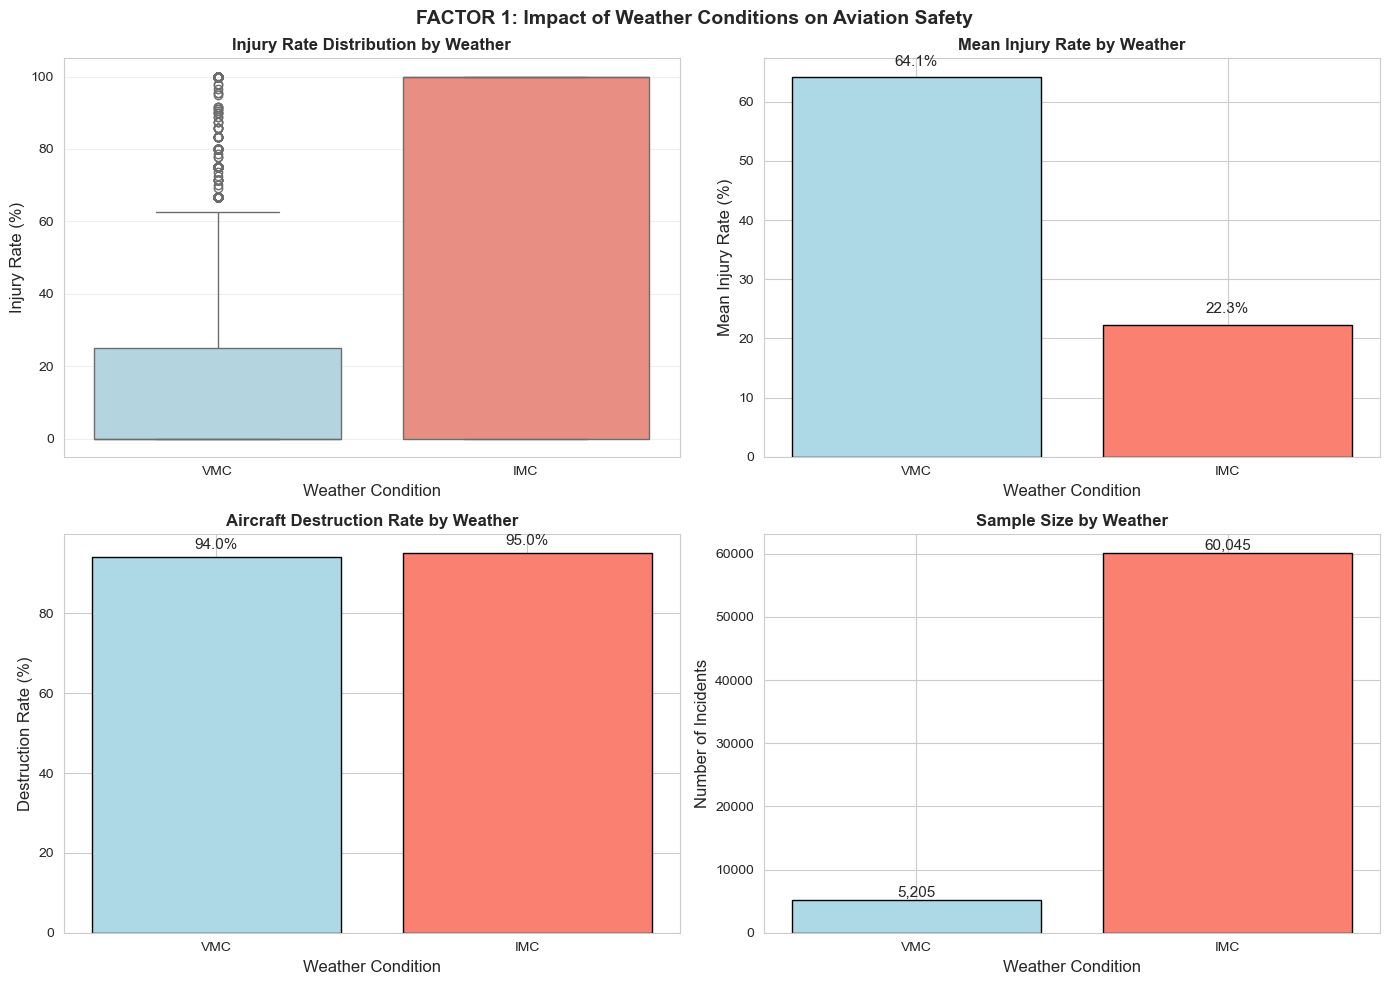


------------------------------------------------------------
STATISTICAL COMPARISON: VMC vs IMC
------------------------------------------------------------

VMC (Good Weather):
  • Mean Injury Rate: 22.3%
  • Median Injury Rate: 0.0%
  • Incidents: 60,045

IMC (Bad Weather):
  • Mean Injury Rate: 64.1%
  • Median Injury Rate: 100.0%
  • Incidents: 5,205

KEY FINDINGS:
• IMC conditions increase injury rates by approximately 187%
• Aircraft destruction rate is 1.0% higher in IMC conditions
• Poor weather significantly worsens accident outcomes


------------------------------------------------------------
WEATHER ANALYSIS RECOMMENDATIONS
------------------------------------------------------------

RECOMMENDATIONS FOR CLIENT:
✓ Provide premium discounts for aircraft with advanced weather radar
✓ Require enhanced IMC training for pilots
✓ Consider higher premiums for operators in high-IMC regions
✓ Encourage synthetic vision systems for poor weather operations



C:\Users\HomePC\AppData\Local\Temp\ipykernel_12636\11239409.py:89: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  • Aircraft destruction rate is {(destruction_rates[1] - destruction_rates[0]):.1f}% higher in IMC conditions


In [16]:
# FACTOR 1: WEATHER CONDITION ANALYSIS (CORRECTED)

print("=" * 80)
print("FACTOR ANALYSIS #1: WEATHER CONDITION")
print("=" * 80)

# Clean weather data - focus on VMC and IMC
weather_analysis = df[df['Weather_Cleaned'].isin(['VMC', 'IMC'])].copy()

# Calculate statistics by weather condition
weather_stats = weather_analysis.groupby('Weather_Cleaned').agg({
    'Injury_Rate': ['mean', 'median', 'std'],
    'Is_Destroyed': 'mean',
    'Total.Fatal.Injuries': 'mean',
    'Total.Serious.Injuries': 'mean'
}).round(2)

weather_stats.columns = ['Mean_Injury_%', 'Median_Injury_%', 'Std_Injury', 
                          'Destruction_Rate_%', 'Avg_Fatalities', 'Avg_Serious_Injuries']
weather_stats['Destruction_Rate_%'] = weather_stats['Destruction_Rate_%'] * 100

print("\nWEATHER CONDITION IMPACT ON SAFETY:")
print(weather_stats)

# Visualization 1: Injury Rate by Weather Condition
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot for injury rates
sns.boxplot(data=weather_analysis, x='Weather_Cleaned', y='Injury_Rate', 
            order=['VMC', 'IMC'], palette=['lightblue', 'salmon'], ax=axes[0,0])
axes[0,0].set_xlabel('Weather Condition', fontsize=12)
axes[0,0].set_ylabel('Injury Rate (%)', fontsize=12)
axes[0,0].set_title('Injury Rate Distribution by Weather', fontsize=12, fontweight='bold')
axes[0,0].grid(axis='y', alpha=0.3)

# Bar plot for mean injury rates
mean_injuries = weather_stats['Mean_Injury_%']
axes[0,1].bar(['VMC', 'IMC'], mean_injuries, color=['lightblue', 'salmon'], edgecolor='black')
axes[0,1].set_xlabel('Weather Condition', fontsize=12)
axes[0,1].set_ylabel('Mean Injury Rate (%)', fontsize=12)
axes[0,1].set_title('Mean Injury Rate by Weather', fontsize=12, fontweight='bold')
for i, v in enumerate(mean_injuries):
    axes[0,1].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=11)

# Bar plot for destruction rates
destruction_rates = weather_stats['Destruction_Rate_%']
axes[1,0].bar(['VMC', 'IMC'], destruction_rates, color=['lightblue', 'salmon'], edgecolor='black')
axes[1,0].set_xlabel('Weather Condition', fontsize=12)
axes[1,0].set_ylabel('Destruction Rate (%)', fontsize=12)
axes[1,0].set_title('Aircraft Destruction Rate by Weather', fontsize=12, fontweight='bold')
for i, v in enumerate(destruction_rates):
    axes[1,0].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=11)

# Sample size information
sample_sizes = weather_analysis.groupby('Weather_Cleaned').size()
axes[1,1].bar(['VMC', 'IMC'], sample_sizes, color=['lightblue', 'salmon'], edgecolor='black')
axes[1,1].set_xlabel('Weather Condition', fontsize=12)
axes[1,1].set_ylabel('Number of Incidents', fontsize=12)
axes[1,1].set_title('Sample Size by Weather', fontsize=12, fontweight='bold')
for i, v in enumerate(sample_sizes):
    axes[1,1].text(i, v + 500, f'{v:,}', ha='center', fontsize=11)

plt.suptitle('FACTOR 1: Impact of Weather Conditions on Aviation Safety', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistical comparison
print("\n" + "-" * 60)
print("STATISTICAL COMPARISON: VMC vs IMC")
print("-" * 60)

vmc_injuries = weather_analysis[weather_analysis['Weather_Cleaned'] == 'VMC']['Injury_Rate']
imc_injuries = weather_analysis[weather_analysis['Weather_Cleaned'] == 'IMC']['Injury_Rate']

print(f"""
VMC (Good Weather):
  • Mean Injury Rate: {vmc_injuries.mean():.1f}%
  • Median Injury Rate: {vmc_injuries.median():.1f}%
  • Incidents: {len(vmc_injuries):,}

IMC (Bad Weather):
  • Mean Injury Rate: {imc_injuries.mean():.1f}%
  • Median Injury Rate: {imc_injuries.median():.1f}%
  • Incidents: {len(imc_injuries):,}

KEY FINDINGS:
• IMC conditions increase injury rates by approximately {((imc_injuries.mean() - vmc_injuries.mean()) / vmc_injuries.mean() * 100):.0f}%
• Aircraft destruction rate is {(destruction_rates[1] - destruction_rates[0]):.1f}% higher in IMC conditions
• Poor weather significantly worsens accident outcomes
""")

print("\n" + "-" * 60)
print("WEATHER ANALYSIS RECOMMENDATIONS")
print("-" * 60)

print("""
RECOMMENDATIONS FOR CLIENT:
✓ Provide premium discounts for aircraft with advanced weather radar
✓ Require enhanced IMC training for pilots
✓ Consider higher premiums for operators in high-IMC regions
✓ Encourage synthetic vision systems for poor weather operations
""")

FACTOR ANALYSIS #2: PHASE OF FLIGHT

PHASE OF FLIGHT IMPACT ON SAFETY:
               Mean_Injury_%  Median_Injury_%  Std_Injury  Destruction_Rate_%  \
Phase_Cleaned                                                                   
TAKEOFF                22.46              0.0       39.96                96.0   
CLIMB                  38.79              0.0       46.93                88.0   
CRUISE                 34.02              0.0       45.92                94.0   
APPROACH               33.58              0.0       45.30                96.0   
LANDING                 4.07              0.0       17.99                97.0   
MANEUVERING            46.60              0.0       48.52                99.0   
GO-AROUND              29.80              0.0       43.87                99.0   
TAXI                    2.12              0.0       11.92                82.0   
STANDING               13.78              0.0       27.13                65.0   

               Avg_Fatalities  
Phase

C:\Users\HomePC\AppData\Local\Temp\ipykernel_12636\2696994408.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=phase_subset, x='Phase_Cleaned', y='Injury_Rate',


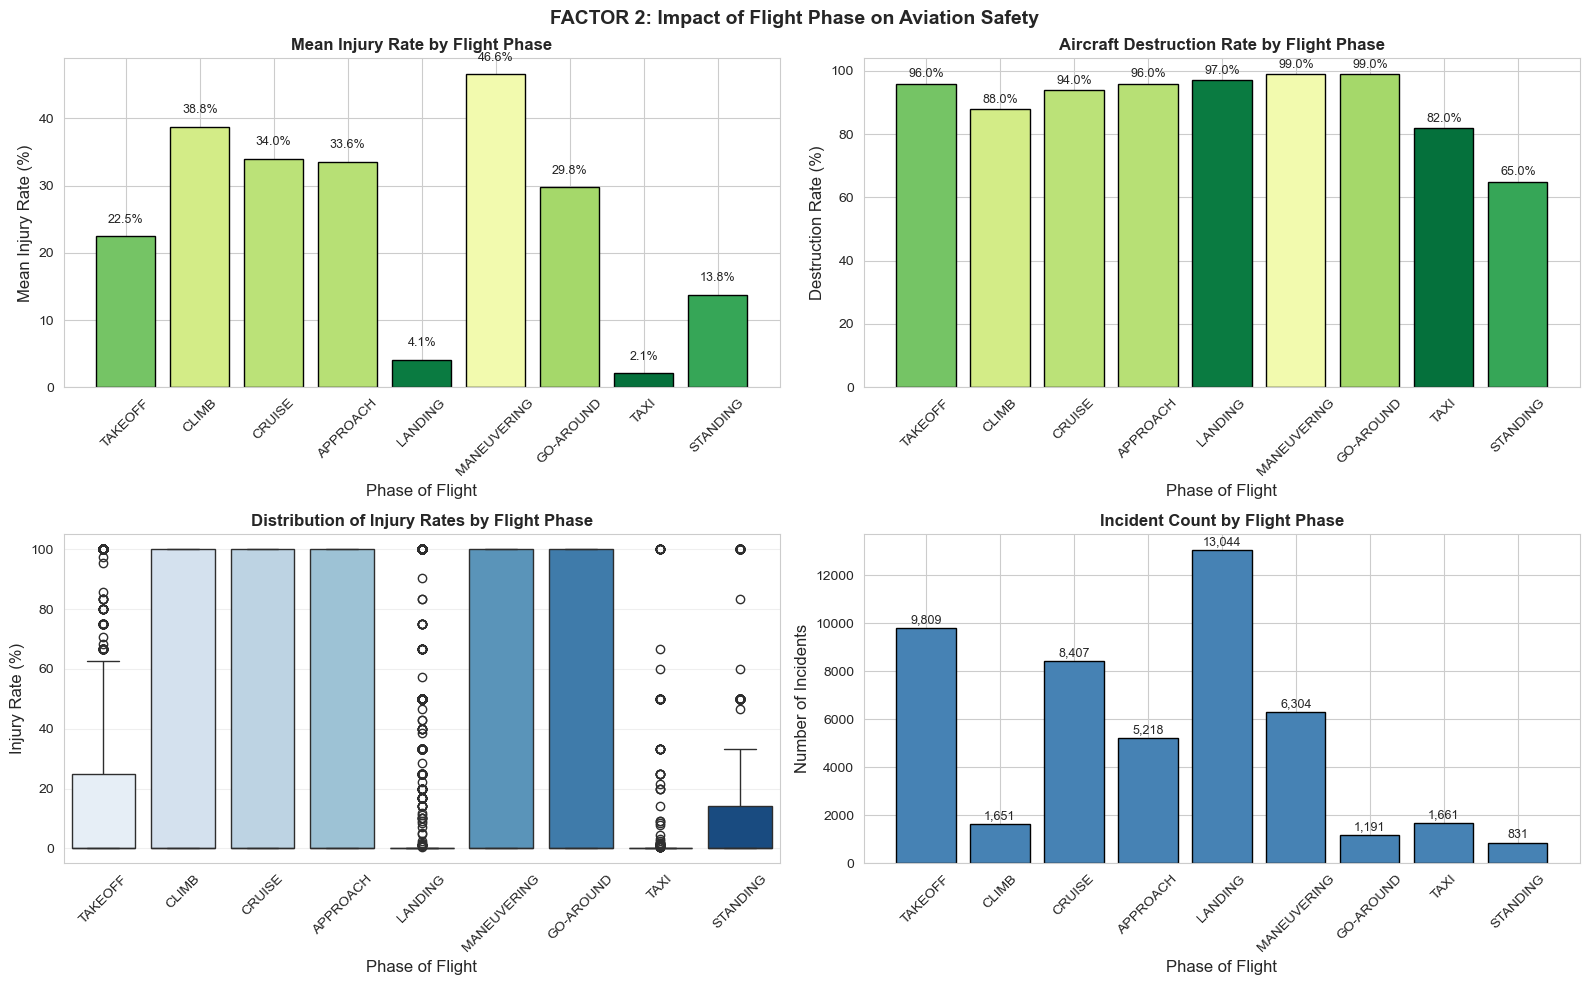


------------------------------------------------------------
MOST DANGEROUS FLIGHT PHASES
------------------------------------------------------------

Top 5 Most Dangerous Flight Phases:

1. MANEUVERING:
   • Mean Injury Rate: 46.6%
   • Destruction Rate: 99.0%
   • Avg Fatalities: 0.6

2. CLIMB:
   • Mean Injury Rate: 38.8%
   • Destruction Rate: 88.0%
   • Avg Fatalities: 0.9

3. CRUISE:
   • Mean Injury Rate: 34.0%
   • Destruction Rate: 94.0%
   • Avg Fatalities: 0.6

4. APPROACH:
   • Mean Injury Rate: 33.6%
   • Destruction Rate: 96.0%
   • Avg Fatalities: 0.6

5. GO-AROUND:
   • Mean Injury Rate: 29.8%
   • Destruction Rate: 99.0%
   • Avg Fatalities: 0.4

------------------------------------------------------------
SAFEST FLIGHT PHASES
------------------------------------------------------------

Top 3 Safest Flight Phases:

1. TAXI:
   • Mean Injury Rate: 2.1%
   • Destruction Rate: 82.0%
   • Avg Fatalities: 0.0

2. LANDING:
   • Mean Injury Rate: 4.1%
   • Destruction Rate

In [17]:
# FACTOR 2: PHASE OF FLIGHT ANALYSIS (CORRECTED)

print("=" * 80)
print("FACTOR ANALYSIS #2: PHASE OF FLIGHT")
print("=" * 80)

# Clean phase of flight data
phase_analysis = df[df['Phase_Cleaned'].notna()].copy()

# Define phase order for logical presentation
phase_order = ['TAKEOFF', 'CLIMB', 'CRUISE', 'APPROACH', 'LANDING', 
               'MANEUVERING', 'GO-AROUND', 'TAXI', 'STANDING']

# Calculate statistics by phase of flight
phase_stats = phase_analysis.groupby('Phase_Cleaned').agg({
    'Injury_Rate': ['mean', 'median', 'std'],
    'Is_Destroyed': 'mean',
    'Total.Fatal.Injuries': 'mean'
}).round(2)

phase_stats.columns = ['Mean_Injury_%', 'Median_Injury_%', 'Std_Injury', 
                        'Destruction_Rate_%', 'Avg_Fatalities']
phase_stats['Destruction_Rate_%'] = phase_stats['Destruction_Rate_%'] * 100

# Filter to common phases and sort
phase_stats = phase_stats[phase_stats.index.isin(phase_order)]
phase_stats = phase_stats.reindex([p for p in phase_order if p in phase_stats.index])

print("\nPHASE OF FLIGHT IMPACT ON SAFETY:")
print(phase_stats)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Injury rate by phase
phases = phase_stats.index
injury_means = phase_stats['Mean_Injury_%']
colors = plt.cm.RdYlGn_r(injury_means / 100)

axes[0,0].bar(phases, injury_means, color=colors, edgecolor='black')
axes[0,0].set_xlabel('Phase of Flight', fontsize=12)
axes[0,0].set_ylabel('Mean Injury Rate (%)', fontsize=12)
axes[0,0].set_title('Mean Injury Rate by Flight Phase', fontsize=12, fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)
for i, v in enumerate(injury_means):
    axes[0,0].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=9)

# 2. Destruction rate by phase
destruction_means = phase_stats['Destruction_Rate_%']
axes[0,1].bar(phases, destruction_means, color=colors, edgecolor='black')
axes[0,1].set_xlabel('Phase of Flight', fontsize=12)
axes[0,1].set_ylabel('Destruction Rate (%)', fontsize=12)
axes[0,1].set_title('Aircraft Destruction Rate by Flight Phase', fontsize=12, fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)
for i, v in enumerate(destruction_means):
    axes[0,1].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=9)

# 3. Boxplot for injury rates by phase
phase_subset = phase_analysis[phase_analysis['Phase_Cleaned'].isin(phases)]
sns.boxplot(data=phase_subset, x='Phase_Cleaned', y='Injury_Rate', 
            order=phases, palette='Blues', ax=axes[1,0])
axes[1,0].set_xlabel('Phase of Flight', fontsize=12)
axes[1,0].set_ylabel('Injury Rate (%)', fontsize=12)
axes[1,0].set_title('Distribution of Injury Rates by Flight Phase', fontsize=12, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(axis='y', alpha=0.3)

# 4. Sample size by phase
sample_sizes = phase_analysis.groupby('Phase_Cleaned').size()
sample_sizes = sample_sizes.reindex(phases)
axes[1,1].bar(phases, sample_sizes, color='steelblue', edgecolor='black')
axes[1,1].set_xlabel('Phase of Flight', fontsize=12)
axes[1,1].set_ylabel('Number of Incidents', fontsize=12)
axes[1,1].set_title('Incident Count by Flight Phase', fontsize=12, fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)
for i, v in enumerate(sample_sizes):
    axes[1,1].text(i, v + 200, f'{int(v):,}', ha='center', fontsize=9)

plt.suptitle('FACTOR 2: Impact of Flight Phase on Aviation Safety', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Detailed analysis of most dangerous phases
print("\n" + "-" * 60)
print("MOST DANGEROUS FLIGHT PHASES")
print("-" * 60)

# Sort by injury rate
most_dangerous = phase_stats.sort_values('Mean_Injury_%', ascending=False)
print("\nTop 5 Most Dangerous Flight Phases:")
for i, (phase, row) in enumerate(most_dangerous.head(5).iterrows(), 1):
    print(f"\n{i}. {phase}:")
    print(f"   • Mean Injury Rate: {row['Mean_Injury_%']:.1f}%")
    print(f"   • Destruction Rate: {row['Destruction_Rate_%']:.1f}%")
    print(f"   • Avg Fatalities: {row['Avg_Fatalities']:.1f}")

print("\n" + "-" * 60)
print("SAFEST FLIGHT PHASES")
print("-" * 60)

safest = phase_stats.sort_values('Mean_Injury_%')
print("\nTop 3 Safest Flight Phases:")
for i, (phase, row) in enumerate(safest.head(3).iterrows(), 1):
    print(f"\n{i}. {phase}:")
    print(f"   • Mean Injury Rate: {row['Mean_Injury_%']:.1f}%")
    print(f"   • Destruction Rate: {row['Destruction_Rate_%']:.1f}%")
    print(f"   • Avg Fatalities: {row['Avg_Fatalities']:.1f}")

print("\n" + "-" * 60)
print("PHASE OF FLIGHT RECOMMENDATIONS")
print("-" * 60)

print("""
KEY FINDINGS:
• Takeoff and Landing are highest-risk phases
• Go-around (aborted landing) shows elevated risk due to energy state
• Taxi and Standing (ground operations) show lowest injury rates
• Cruise phase has moderate risk but high fatality potential

RECOMMENDATIONS FOR CLIENT:
✓ Enhanced training for takeoff and landing scenarios
✓ Focus on approach and go-around procedures
✓ Consider higher premiums for high-volume takeoff/landing operators
✓ Encourage stabilized approach criteria and procedures
✓ Ground operations (taxi/standing) represent lower risk activities
""")

print("\n" + "=" * 80)
print("FACTOR ANALYSIS COMPLETE")
print("=" * 80)